# Part 2: PINN 求解 curl curl u + u = f (PyTorch 环境)

## 问题描述

在 2D L-shape 域 $\Omega = [-1,1]^2 \setminus [0,1] \times [-1,0]$ 上：

$$\nabla \times \nabla \times \mathbf{u} + \mathbf{u} = \mathbf{f}, \quad \mathbf{u} \times \mathbf{n} = 0 \text{ on } \partial\Omega$$

以 `FEM_nedelec_curlcurl.ipynb` 生成的 Nédélec FEM 解为 Ground Truth，训练 PINN 并对比分析。

### 数据来源

- `fem_curlcurl_data.npz`: 内部/边界采样点 + FEM 解值 + f 值 (PINN 训练用)
- `fem_grid_data.npz`: 规则网格上的 FEM 解 (对比可视化用)

> **环境要求**: 本 notebook 仅需 `torch`, `numpy`, `matplotlib`，不需要 NGSolve。

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 加载 FEM 采样数据 (由 FEM_nedelec_curlcurl.ipynb 生成)
data = np.load('fem_curlcurl_data.npz')
x_col = torch.tensor(data['x_int'], dtype=torch.float32).to(device)   # 配置点坐标 (PDE残差计算用)
u_fem = torch.tensor(data['u_int'], dtype=torch.float32).to(device)   # FEM解值 (仅用于事后误差对比, 不参与训练!)
x_bc  = torch.tensor(data['x_bnd'], dtype=torch.float32).to(device)   # 边界点坐标 (BC损失用)

# ============ 右端项 f 直接解析计算，不依赖 FEM 采样 ============
# f(x,y) = (sin(πy), sin(πx))  —— 解析已知，无需从 FEM 加载
f_rhs = torch.stack([
    torch.sin(np.pi * x_col[:, 1]),   # f₁ = sin(πy)
    torch.sin(np.pi * x_col[:, 0])    # f₂ = sin(πx)
], dim=1).to(device)

# ============ 边界切向量：根据 L-shape 各边解析计算 ============
# L-shape 边界 6 条边及其切向量:
#   bottom:      (-1,-1) → (0,-1),   t = (1, 0)
#   reentrant_v: (0,-1)  → (0, 0),   t = (0, 1)
#   reentrant_h: (0, 0)  → (1, 0),   t = (1, 0)
#   right:       (1, 0)  → (1, 1),   t = (0, 1)
#   top:         (1, 1)  → (-1,1),   t = (-1,0)   [归一化 → (-1,0)]
#   left:        (-1,1)  → (-1,-1),  t = (0,-1)
#
# u × n = 0 在 2D 中等价于 u · t = 0 (切向分量为零)
# 因此 BC loss = Σ (u · t)² ，只约束切向分量，不涉及法向 —— 纯解析施加！

def compute_tangent_vectors(x_bnd):
    """为每个边界点计算所在边的单位切向量 (解析几何判断)"""
    x, y = x_bnd[:, 0], x_bnd[:, 1]
    tx = torch.zeros_like(x)
    ty = torch.zeros_like(y)
    eps = 1e-4  # 边界判定容差

    # bottom: y ≈ -1, x ∈ [-1, 0]
    mask = (torch.abs(y - (-1)) < eps) & (x >= -1 - eps) & (x <= 0 + eps)
    tx[mask], ty[mask] = 1.0, 0.0

    # reentrant_v: x ≈ 0, y ∈ [-1, 0]
    mask = (torch.abs(x - 0) < eps) & (y >= -1 - eps) & (y <= 0 + eps)
    tx[mask], ty[mask] = 0.0, 1.0

    # reentrant_h: y ≈ 0, x ∈ [0, 1]
    mask = (torch.abs(y - 0) < eps) & (x >= 0 - eps) & (x <= 1 + eps)
    tx[mask], ty[mask] = 1.0, 0.0

    # right: x ≈ 1, y ∈ [0, 1]
    mask = (torch.abs(x - 1) < eps) & (y >= 0 - eps) & (y <= 1 + eps)
    tx[mask], ty[mask] = 0.0, 1.0

    # top: y ≈ 1, x ∈ [-1, 1]
    mask = (torch.abs(y - 1) < eps) & (x >= -1 - eps) & (x <= 1 + eps)
    tx[mask], ty[mask] = -1.0, 0.0  # 方向: (1,1)→(-1,1)

    # left: x ≈ -1, y ∈ [-1, 1]
    mask = (torch.abs(x - (-1)) < eps) & (y >= -1 - eps) & (y <= 1 + eps)
    tx[mask], ty[mask] = 0.0, -1.0  # 方向: (-1,1)→(-1,-1)

    tangents = torch.stack([tx, ty], dim=1)
    return tangents

bc_tangents = compute_tangent_vectors(x_bc)  # [N_bc, 2] 每个边界点的切向量

# 验证: 所有边界点都被分配到了切向量
unassigned = (bc_tangents.abs().sum(dim=1) < 1e-8).sum().item()
print(f'Boundary points: {x_bc.shape[0]}, unassigned tangents: {unassigned}')
if unassigned > 0:
    print('⚠️ WARNING: some boundary points have no tangent assigned!')

print(f'Interior points: {x_col.shape}, Boundary points: {x_bc.shape}')
print(f'f_rhs: analytically computed f=(sin(πy), sin(πx)), NOT loaded from FEM')


Using device: cuda
Boundary points: 3000, unassigned tangents: 0
Interior points: torch.Size([10000, 2]), Boundary points: torch.Size([3000, 2])
f_rhs: analytically computed f=(sin(πy), sin(πx)), NOT loaded from FEM


In [ ]:
# ===================== PINN 向量网络 =====================
class ReLU2(nn.Module):
    def forward(self, x):
        return torch.pow(torch.relu(x), 2)

class VectorPINN(nn.Module):
    def __init__(self, activation_name='tanh', hidden_dim=128, n_layers=4):
        super().__init__()
        self.activation_name = activation_name
        if activation_name == 'tanh': act = nn.Tanh()
        elif activation_name == 'relu2': act = ReLU2()
        elif activation_name == 'gelu': act = nn.GELU()
        else: act = nn.Tanh()
        
        layers = [nn.Linear(2, hidden_dim), act]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), act]
        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)
        
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)


In [23]:
# ===================== PDE 残差: curl curl u + u - f = 0 =====================
#
# 在 2D 中, u = (u₁, u₂):
#   curl u (标量) = ∂u₂/∂x - ∂u₁/∂y
#   curl curl u (向量) = (∂(curl u)/∂y, -∂(curl u)/∂x)
#
# 因此 PDE 残差:
#   res_x = ∂(curl u)/∂y + u₁ - f₁ = 0
#   res_y = -∂(curl u)/∂x + u₂ - f₂ = 0

def curlcurl_residual(model, x_in, f_rhs):
    x_in = x_in.detach().requires_grad_(True)
    u = model(x_in)
    u1, u2 = u[:, 0:1], u[:, 1:2]
    
    # 计算 grad u₁ 和 grad u₂
    grad_u1 = torch.autograd.grad(u1, x_in, torch.ones_like(u1), create_graph=True)[0]
    grad_u2 = torch.autograd.grad(u2, x_in, torch.ones_like(u2), create_graph=True)[0]
    du1_dy = grad_u1[:, 1:2]  # ∂u₁/∂y
    du2_dx = grad_u2[:, 0:1]  # ∂u₂/∂x
    
    # 标量 curl: curl u = ∂u₂/∂x - ∂u₁/∂y
    scalar_curl = du2_dx - du1_dy
    
    # curl curl u 需要对标量 curl 再取梯度
    grad_curl = torch.autograd.grad(scalar_curl, x_in, torch.ones_like(scalar_curl), create_graph=True)[0]
    # grad_curl[:, 0] = ∂(curl u)/∂x
    # grad_curl[:, 1] = ∂(curl u)/∂y
    
    # curl curl u = (∂(curl u)/∂y, -∂(curl u)/∂x)
    # PDE: curl curl u + u = f
    res_x =  grad_curl[:, 1:2] + u1 - f_rhs[:, 0:1]   # ∂(curl u)/∂y + u₁ - f₁
    res_y = -grad_curl[:, 0:1] + u2 - f_rhs[:, 1:2]   # -∂(curl u)/∂x + u₂ - f₂
    return res_x, res_y


In [24]:
# ===================== Phase 1 训练 (Adam + StepLR) =====================
ACT_TYPE = 'tanh'
model = VectorPINN(ACT_TYPE, hidden_dim=128, n_layers=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

w_pde, w_bc = 1.0, 50.0
loss_history = []

# ============================================================
# PINN 训练仅使用:
#   1) PDE 残差 loss_pde = ||curl curl u + u - f||²  (f 解析计算)
#   2) BC 损失  loss_bc  = ||u · t||²                 (切向分量=0, 解析施加)
#
# 不使用任何 FEM 解值做监督! FEM 数据仅用于训练后的误差对比验证.
# ============================================================
print(f'--- Training PINN ({ACT_TYPE}), params={sum(p.numel() for p in model.parameters())} ---')
print(f'    BC loss: |u · t|² (tangential component only, analytically imposed)')
print(f'    f_rhs:   sin(πy), sin(πx) (analytically computed)')

for epoch in range(20001):
    optimizer.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)

    # BC: u × n = 0  ⟺  u · t = 0  (只惩罚切向分量, 法向不约束)
    u_bc_pred = model(x_bc)
    tangential_component = (u_bc_pred * bc_tangents).sum(dim=1)  # u · t
    loss_bc = torch.mean(tangential_component**2)

    loss = w_pde * loss_pde + w_bc * loss_bc
    loss.backward(); optimizer.step(); scheduler.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e})')


--- Training PINN (tanh), params=50178 ---
    BC loss: |u · t|² (tangential component only, analytically imposed)
    f_rhs:   sin(πy), sin(πx) (analytically computed)
Epoch     0: Loss=2.1124e+00 (PDE=9.224e-01, BC=2.380e-02)
Epoch  2000: Loss=4.9419e-03 (PDE=4.304e-03, BC=1.276e-05)
Epoch  2000: Loss=4.9419e-03 (PDE=4.304e-03, BC=1.276e-05)
Epoch  4000: Loss=1.4272e-03 (PDE=7.392e-04, BC=1.376e-05)
Epoch  4000: Loss=1.4272e-03 (PDE=7.392e-04, BC=1.376e-05)
Epoch  6000: Loss=3.5357e-04 (PDE=3.276e-04, BC=5.199e-07)
Epoch  6000: Loss=3.5357e-04 (PDE=3.276e-04, BC=5.199e-07)
Epoch  8000: Loss=7.8123e-04 (PDE=2.720e-04, BC=1.019e-05)
Epoch  8000: Loss=7.8123e-04 (PDE=2.720e-04, BC=1.019e-05)
Epoch 10000: Loss=2.2638e-04 (PDE=1.878e-04, BC=7.708e-07)
Epoch 10000: Loss=2.2638e-04 (PDE=1.878e-04, BC=7.708e-07)
Epoch 12000: Loss=1.5527e-04 (PDE=1.398e-04, BC=3.093e-07)
Epoch 12000: Loss=1.5527e-04 (PDE=1.398e-04, BC=3.093e-07)
Epoch 14000: Loss=1.1762e-04 (PDE=1.025e-04, BC=3.026e-07)
Epoch

In [25]:
# ===================== Phase 2 微调训练 =====================
optimizer2 = optim.Adam(model.parameters(), lr=1e-4)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=5000, gamma=0.5)

for epoch in range(20001, 40001):
    optimizer2.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)

    # BC: u · t = 0 (切向分量为零, 解析施加)
    u_bc_pred = model(x_bc)
    tangential_component = (u_bc_pred * bc_tangents).sum(dim=1)
    loss_bc = torch.mean(tangential_component**2)

    loss = w_pde * loss_pde + w_bc * loss_bc
    loss.backward(); optimizer2.step(); scheduler2.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e})')


Epoch 22000: Loss=3.4053e-05 (PDE=2.409e-05, BC=1.992e-07)
Epoch 24000: Loss=2.7180e-05 (PDE=1.929e-05, BC=1.578e-07)
Epoch 24000: Loss=2.7180e-05 (PDE=1.929e-05, BC=1.578e-07)
Epoch 26000: Loss=2.2161e-05 (PDE=1.609e-05, BC=1.214e-07)
Epoch 26000: Loss=2.2161e-05 (PDE=1.609e-05, BC=1.214e-07)
Epoch 28000: Loss=2.4035e-05 (PDE=1.358e-05, BC=2.091e-07)
Epoch 28000: Loss=2.4035e-05 (PDE=1.358e-05, BC=2.091e-07)
Epoch 30000: Loss=2.2646e-05 (PDE=1.181e-05, BC=2.167e-07)
Epoch 30000: Loss=2.2646e-05 (PDE=1.181e-05, BC=2.167e-07)
Epoch 32000: Loss=1.3536e-05 (PDE=9.920e-06, BC=7.233e-08)
Epoch 32000: Loss=1.3536e-05 (PDE=9.920e-06, BC=7.233e-08)
Epoch 34000: Loss=2.0670e-05 (PDE=9.126e-06, BC=2.309e-07)
Epoch 34000: Loss=2.0670e-05 (PDE=9.126e-06, BC=2.309e-07)
Epoch 36000: Loss=9.9100e-06 (PDE=7.729e-06, BC=4.362e-08)
Epoch 36000: Loss=9.9100e-06 (PDE=7.729e-06, BC=4.362e-08)
Epoch 38000: Loss=8.9664e-06 (PDE=6.918e-06, BC=4.097e-08)
Epoch 38000: Loss=8.9664e-06 (PDE=6.918e-06, BC=4.097e-0

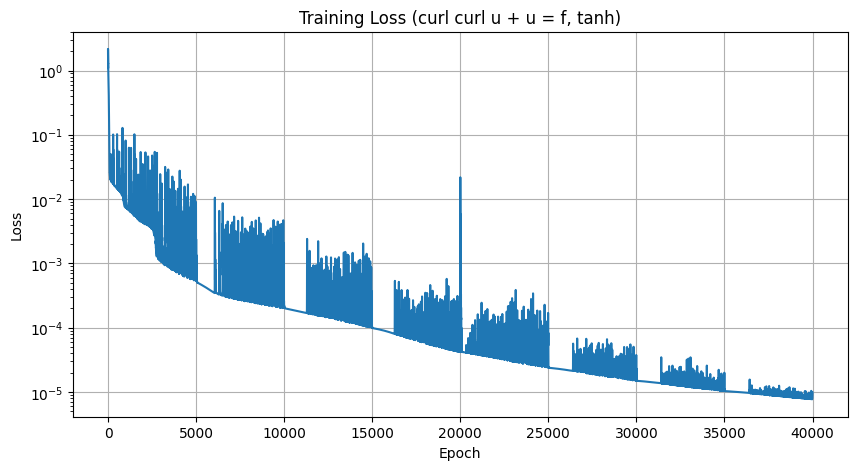

In [26]:
# ===================== Loss 曲线 =====================
plt.figure(figsize=(10, 5))
plt.semilogy(loss_history)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Training Loss (curl curl u + u = f, {ACT_TYPE})')
plt.grid(True); plt.show()


In [27]:
# ===================== PINN 网格评估函数 =====================
def evaluate_on_grid(model, device, x_range, y_range, n_grid=120):
    """在规则网格上评估 PINN 模型, L-shape 缺失区域设为 NaN"""
    xv = np.linspace(x_range[0], x_range[1], n_grid)
    yv = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(xv, yv)
    XY_torch = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32).to(device)
    mask = (X > 0) & (Y < 0)
    with torch.no_grad():
        U = model(XY_torch).cpu().numpy()
    ux = U[:,0].reshape(n_grid, n_grid)
    uy = U[:,1].reshape(n_grid, n_grid)
    umag = np.sqrt(ux**2 + uy**2)
    ux[mask] = np.nan; uy[mask] = np.nan; umag[mask] = np.nan
    return X, Y, ux, uy, umag, mask


Evaluating PINN on 100x100 grid...


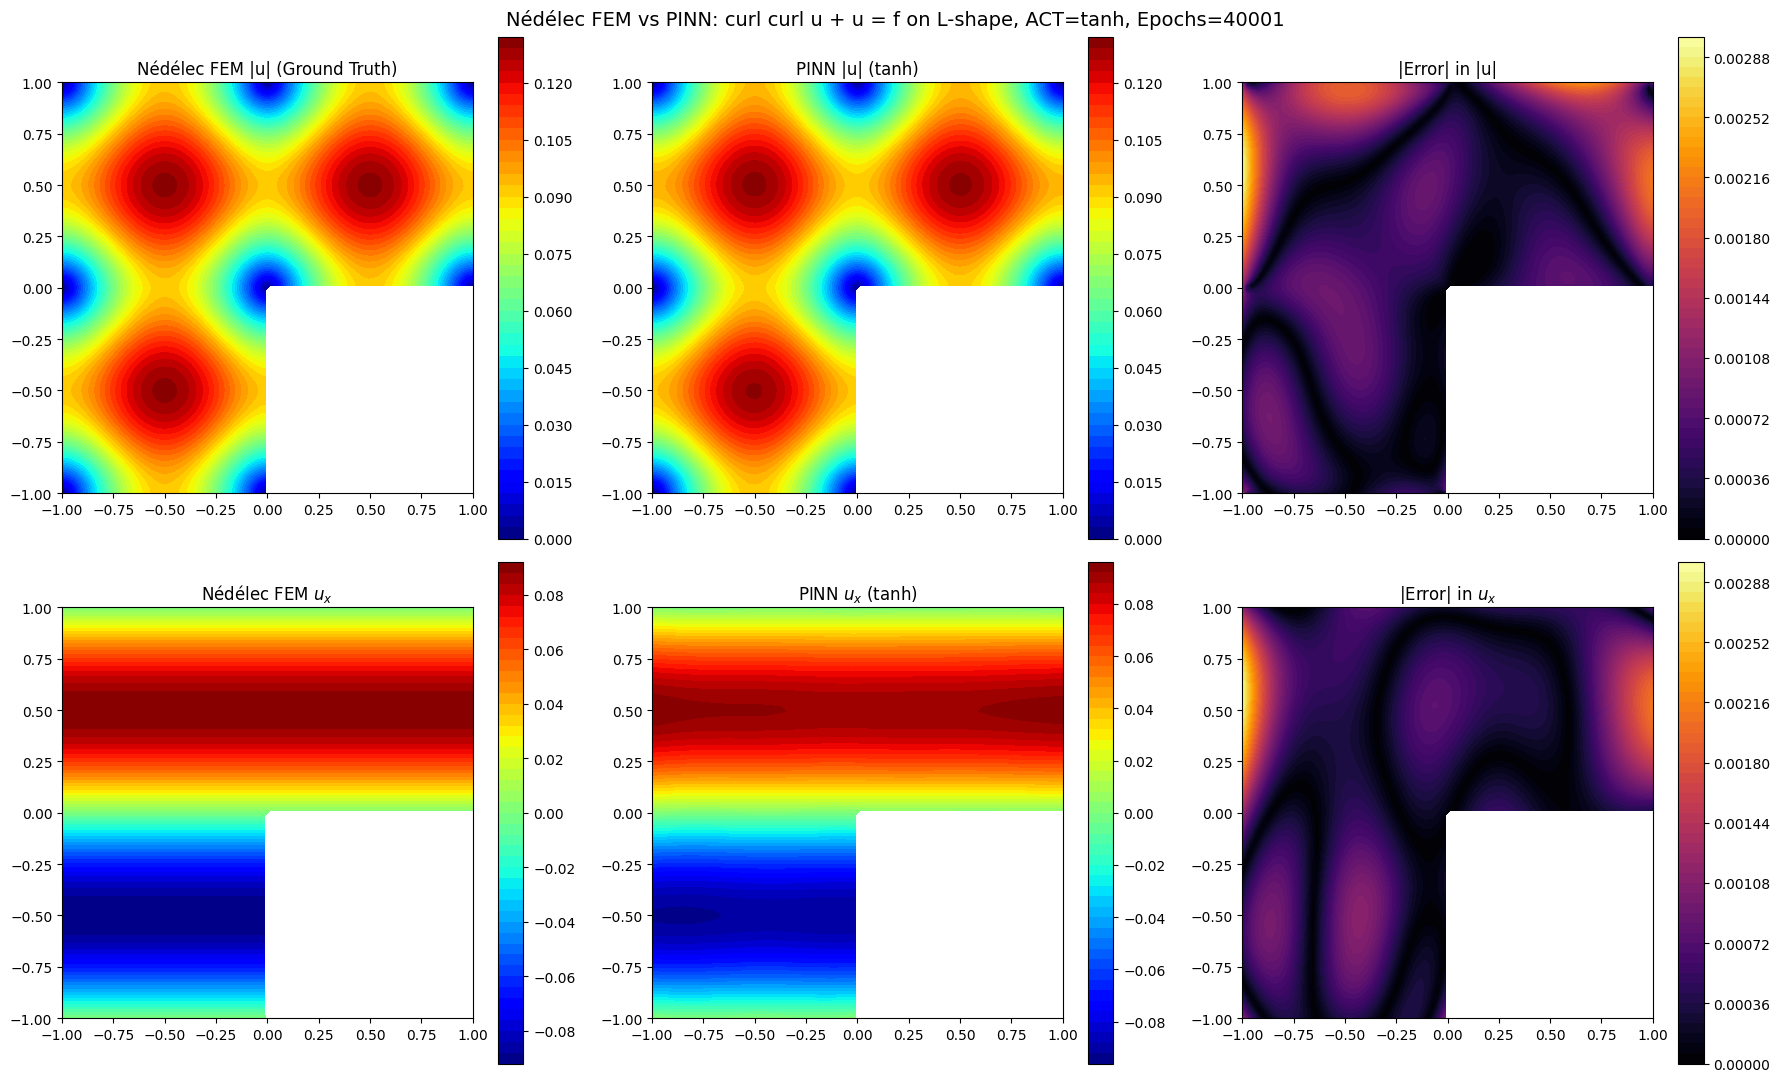


=== Error Statistics ===
  Max |u| error:  2.968876e-03
  Mean |u| error: 6.115211e-04
  L2 relative:    8.680831e-03


In [28]:
# ===================== 加载 FEM 网格数据并对比可视化 =====================
# 从 fem_grid_data.npz 加载预计算的 FEM 网格解 (无需 ngsolve!)
fem_grid = np.load('fem_grid_data.npz')
Xf, Yf = fem_grid['Xf'], fem_grid['Yf']
uxf, uyf, uf = fem_grid['uxf'], fem_grid['uyf'], fem_grid['uf']

# PINN 在同样网格上评估
ng = Xf.shape[0]
print(f'Evaluating PINN on {ng}x{ng} grid...')
Xp, Yp, uxp, uyp, up, mp = evaluate_on_grid(model, device, (-1, 1), (-1, 1), ng)

# --- FEM vs PINN 对比 (2×3 子图) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

im00 = axes[0,0].contourf(Xf, Yf, uf, levels=50, cmap='jet')
axes[0,0].set_title('Nédélec FEM |u| (Ground Truth)'); axes[0,0].set_aspect('equal'); fig.colorbar(im00, ax=axes[0,0])

im01 = axes[0,1].contourf(Xp, Yp, up, levels=50, cmap='jet')
axes[0,1].set_title(f'PINN |u| ({ACT_TYPE})'); axes[0,1].set_aspect('equal'); fig.colorbar(im01, ax=axes[0,1])

err_mag = np.abs(up - uf)
im02 = axes[0,2].contourf(Xf, Yf, err_mag, levels=50, cmap='inferno')
axes[0,2].set_title('|Error| in |u|'); axes[0,2].set_aspect('equal'); fig.colorbar(im02, ax=axes[0,2])

im10 = axes[1,0].contourf(Xf, Yf, uxf, levels=50, cmap='jet')
axes[1,0].set_title(r'Nédélec FEM $u_x$'); axes[1,0].set_aspect('equal'); fig.colorbar(im10, ax=axes[1,0])

im11 = axes[1,1].contourf(Xp, Yp, uxp, levels=50, cmap='jet')
axes[1,1].set_title(f'PINN $u_x$ ({ACT_TYPE})'); axes[1,1].set_aspect('equal'); fig.colorbar(im11, ax=axes[1,1])

err_ux = np.abs(uxp - uxf)
im12 = axes[1,2].contourf(Xf, Yf, err_ux, levels=50, cmap='inferno')
axes[1,2].set_title(r'|Error| in $u_x$'); axes[1,2].set_aspect('equal'); fig.colorbar(im12, ax=axes[1,2])

plt.suptitle(f'Nédélec FEM vs PINN: curl curl u + u = f on L-shape, ACT={ACT_TYPE}, Epochs={len(loss_history)}', fontsize=14)
plt.tight_layout(); plt.show()

print(f'\n=== Error Statistics ===')
print(f'  Max |u| error:  {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| error: {np.nanmean(err_mag):.6e}')
print(f'  L2 relative:    {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')


Evaluating PINN on zoom grid 100x100 near re-entrant corner...


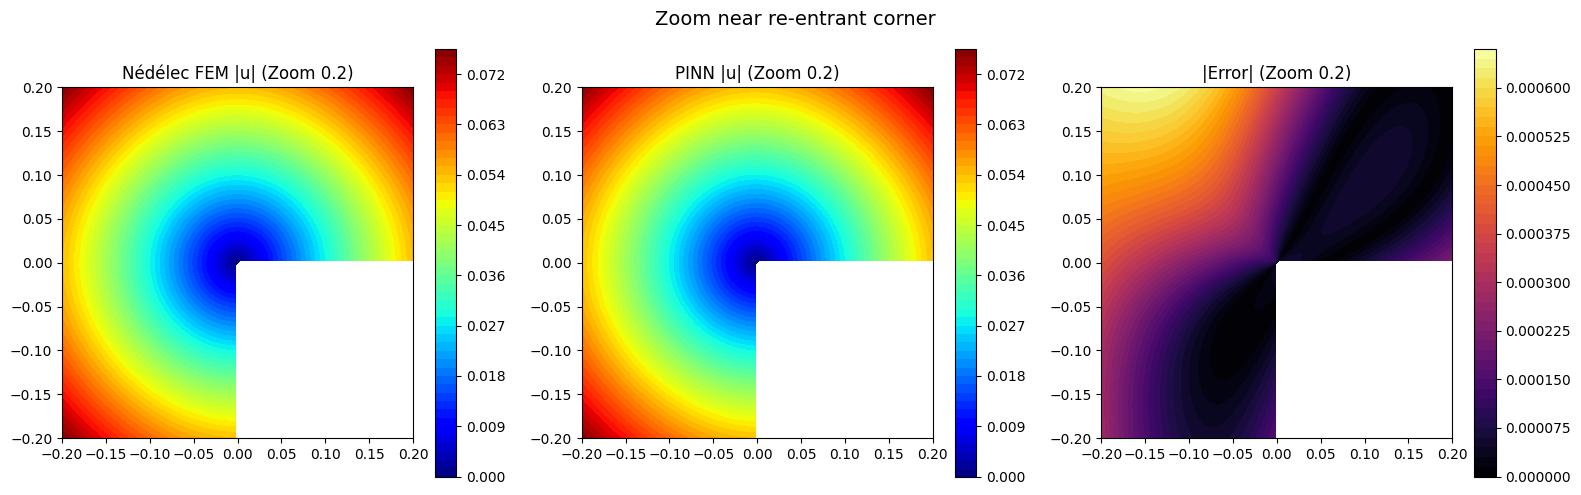

Zoom - Max err: 6.510679e-04, Mean err: 2.041079e-04


In [29]:
# ===================== Zoom-in 凹角附近误差分析 =====================
# 加载预计算的 FEM zoom 数据
Xfz, Yfz = fem_grid['Xfz'], fem_grid['Yfz']
ufz = fem_grid['ufz']

nz = Xfz.shape[0]
print(f'Evaluating PINN on zoom grid {nz}x{nz} near re-entrant corner...')
Xpz, Ypz, _, _, upz, _ = evaluate_on_grid(model, device, (-0.2, 0.2), (-0.2, 0.2), nz)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xfz, Yfz, ufz, levels=50, cmap='jet')
axes[0].set_title('Nédélec FEM |u| (Zoom 0.2)'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xpz, Ypz, upz, levels=50, cmap='jet')
axes[1].set_title('PINN |u| (Zoom 0.2)'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_z = np.abs(upz - ufz)
im2 = axes[2].contourf(Xfz, Yfz, err_z, levels=50, cmap='inferno')
axes[2].set_title('|Error| (Zoom 0.2)'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle('Zoom near re-entrant corner', fontsize=14); plt.tight_layout(); plt.show()
print(f'Zoom - Max err: {np.nanmax(err_z):.6e}, Mean err: {np.nanmean(err_z):.6e}')


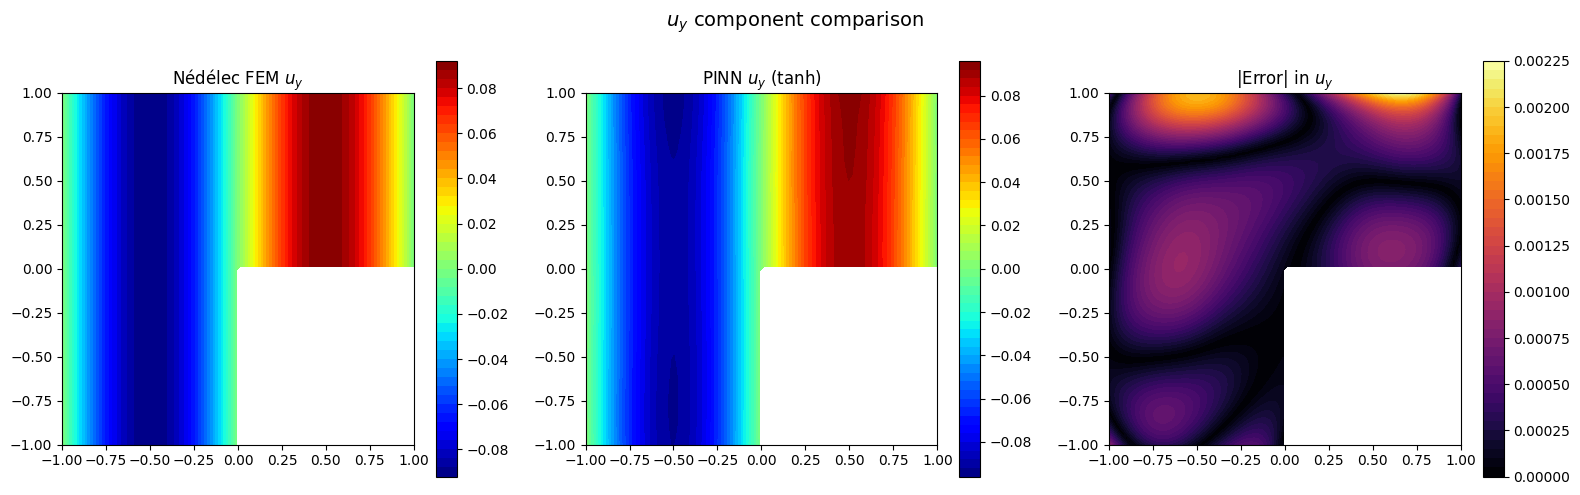

In [30]:
# ===================== u_y 分量对比可视化 =====================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xf, Yf, uyf, levels=50, cmap='jet')
axes[0].set_title(r'Nédélec FEM $u_y$'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xp, Yp, uyp, levels=50, cmap='jet')
axes[1].set_title(f'PINN $u_y$ ({ACT_TYPE})'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_uy = np.abs(uyp - uyf)
im2 = axes[2].contourf(Xf, Yf, err_uy, levels=50, cmap='inferno')
axes[2].set_title(r'|Error| in $u_y$'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle(r'$u_y$ component comparison', fontsize=14); plt.tight_layout(); plt.show()


In [ ]:
# ===================== 保存模型与误差汇总 =====================
torch.save({'model_state_dict': model.state_dict(), 'activation': ACT_TYPE,
            'loss_history': loss_history, 'epochs': len(loss_history)}, 'pinn_curlcurl_model.pth')

print(f'\n{"="*55}')
print(f'  Final Results Summary')
print(f'{"="*55}')
print(f'  Equation:    curl curl u + u = f')
print(f'  Domain:      L-shape [-1,1]² \\ [0,1]×[-1,0]')
print(f'  FEM:         Nédélec edge elements (HCurl), order=3')
print(f'  BC:          u × n = 0 (tangential homogeneous)')
print(f'  f:           (sin(πy), sin(πx))')
print(f'  Activation:  {ACT_TYPE}')
print(f'  Total epochs:{len(loss_history)}')
print(f'  Final loss:  {loss_history[-1]:.6e}')
print(f'  Max |u| err: {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| err:{np.nanmean(err_mag):.6e}')
print(f'  L2 relative: {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')



  Final Results Summary
  Equation:    curl curl u + u = f
  Domain:      L-shape [-1,1]² \ [0,1]×[-1,0]
  FEM:         Nédélec edge elements (HCurl), order=2
  BC:          u × n = 0 (tangential homogeneous)
  f:           (sin(πy), sin(πx))
  Activation:  tanh
  Total epochs:40001
  Final loss:  9.835181e-06
  Max |u| err: 2.968876e-03
  Mean |u| err:6.115211e-04
  L2 relative: 8.680831e-03


In [32]:
# ===================== Phase 1 训练 (Adam + StepLR) =====================
ACT_TYPE = 'relu2'
model = VectorPINN(ACT_TYPE, hidden_dim=128, n_layers=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

w_pde, w_bc = 1.0, 50.0
loss_history = []

# ============================================================
# PINN 训练仅使用:
#   1) PDE 残差 loss_pde = ||curl curl u + u - f||²  (f 解析计算)
#   2) BC 损失  loss_bc  = ||u · t||²                 (切向分量=0, 解析施加)
#
# 不使用任何 FEM 解值做监督! FEM 数据仅用于训练后的误差对比验证.
# ============================================================
print(f'--- Training PINN ({ACT_TYPE}), params={sum(p.numel() for p in model.parameters())} ---')
print(f'    BC loss: |u · t|² (tangential component only, analytically imposed)')
print(f'    f_rhs:   sin(πy), sin(πx) (analytically computed)')

for epoch in range(20001):
    optimizer.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)

    # BC: u × n = 0  ⟺  u · t = 0  (只惩罚切向分量, 法向不约束)
    u_bc_pred = model(x_bc)
    tangential_component = (u_bc_pred * bc_tangents).sum(dim=1)  # u · t
    loss_bc = torch.mean(tangential_component**2)

    loss = w_pde * loss_pde + w_bc * loss_bc
    loss.backward(); optimizer.step(); scheduler.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e})')


--- Training PINN (relu2), params=50178 ---
    BC loss: |u · t|² (tangential component only, analytically imposed)
    f_rhs:   sin(πy), sin(πx) (analytically computed)
Epoch     0: Loss=1.3642e+00 (PDE=1.001e+00, BC=7.260e-03)
Epoch     0: Loss=1.3642e+00 (PDE=1.001e+00, BC=7.260e-03)
Epoch  2000: Loss=3.7569e-03 (PDE=3.640e-03, BC=2.342e-06)
Epoch  2000: Loss=3.7569e-03 (PDE=3.640e-03, BC=2.342e-06)
Epoch  4000: Loss=7.3519e-04 (PDE=5.704e-04, BC=3.295e-06)
Epoch  4000: Loss=7.3519e-04 (PDE=5.704e-04, BC=3.295e-06)
Epoch  6000: Loss=2.9639e-04 (PDE=2.198e-04, BC=1.532e-06)
Epoch  6000: Loss=2.9639e-04 (PDE=2.198e-04, BC=1.532e-06)
Epoch  8000: Loss=1.4123e-03 (PDE=2.454e-04, BC=2.334e-05)
Epoch  8000: Loss=1.4123e-03 (PDE=2.454e-04, BC=2.334e-05)
Epoch 10000: Loss=1.3096e-04 (PDE=1.076e-04, BC=4.673e-07)
Epoch 10000: Loss=1.3096e-04 (PDE=1.076e-04, BC=4.673e-07)
Epoch 12000: Loss=2.0294e-04 (PDE=8.159e-05, BC=2.427e-06)
Epoch 12000: Loss=2.0294e-04 (PDE=8.159e-05, BC=2.427e-06)
Epoc

In [33]:
# ===================== Phase 2 微调训练 =====================
optimizer2 = optim.Adam(model.parameters(), lr=1e-4)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=5000, gamma=0.5)

for epoch in range(20001, 40001):
    optimizer2.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)

    # BC: u · t = 0 (切向分量为零, 解析施加)
    u_bc_pred = model(x_bc)
    tangential_component = (u_bc_pred * bc_tangents).sum(dim=1)
    loss_bc = torch.mean(tangential_component**2)

    loss = w_pde * loss_pde + w_bc * loss_bc
    loss.backward(); optimizer2.step(); scheduler2.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e})')


Epoch 22000: Loss=1.8058e-05 (PDE=1.537e-05, BC=5.371e-08)
Epoch 24000: Loss=1.5809e-05 (PDE=1.224e-05, BC=7.144e-08)
Epoch 24000: Loss=1.5809e-05 (PDE=1.224e-05, BC=7.144e-08)
Epoch 26000: Loss=1.1579e-05 (PDE=9.987e-06, BC=3.182e-08)
Epoch 26000: Loss=1.1579e-05 (PDE=9.987e-06, BC=3.182e-08)
Epoch 28000: Loss=9.7486e-06 (PDE=8.015e-06, BC=3.468e-08)
Epoch 28000: Loss=9.7486e-06 (PDE=8.015e-06, BC=3.468e-08)
Epoch 30000: Loss=8.0044e-06 (PDE=6.504e-06, BC=3.001e-08)
Epoch 30000: Loss=8.0044e-06 (PDE=6.504e-06, BC=3.001e-08)
Epoch 32000: Loss=6.3416e-06 (PDE=5.436e-06, BC=1.812e-08)
Epoch 32000: Loss=6.3416e-06 (PDE=5.436e-06, BC=1.812e-08)
Epoch 34000: Loss=6.9042e-06 (PDE=4.587e-06, BC=4.635e-08)
Epoch 34000: Loss=6.9042e-06 (PDE=4.587e-06, BC=4.635e-08)
Epoch 36000: Loss=4.4133e-06 (PDE=3.799e-06, BC=1.230e-08)
Epoch 36000: Loss=4.4133e-06 (PDE=3.799e-06, BC=1.230e-08)
Epoch 38000: Loss=3.7951e-06 (PDE=3.205e-06, BC=1.181e-08)
Epoch 38000: Loss=3.7951e-06 (PDE=3.205e-06, BC=1.181e-0

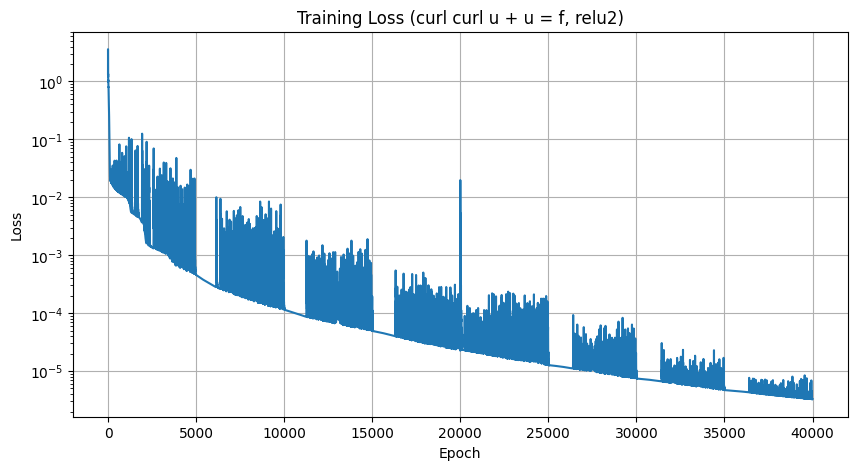

In [34]:
# ===================== Loss 曲线 =====================
plt.figure(figsize=(10, 5))
plt.semilogy(loss_history)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Training Loss (curl curl u + u = f, {ACT_TYPE})')
plt.grid(True); plt.show()


In [35]:
# ===================== PINN 网格评估函数 =====================
def evaluate_on_grid(model, device, x_range, y_range, n_grid=120):
    """在规则网格上评估 PINN 模型, L-shape 缺失区域设为 NaN"""
    xv = np.linspace(x_range[0], x_range[1], n_grid)
    yv = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(xv, yv)
    XY_torch = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32).to(device)
    mask = (X > 0) & (Y < 0)
    with torch.no_grad():
        U = model(XY_torch).cpu().numpy()
    ux = U[:,0].reshape(n_grid, n_grid)
    uy = U[:,1].reshape(n_grid, n_grid)
    umag = np.sqrt(ux**2 + uy**2)
    ux[mask] = np.nan; uy[mask] = np.nan; umag[mask] = np.nan
    return X, Y, ux, uy, umag, mask


Evaluating PINN on 100x100 grid...


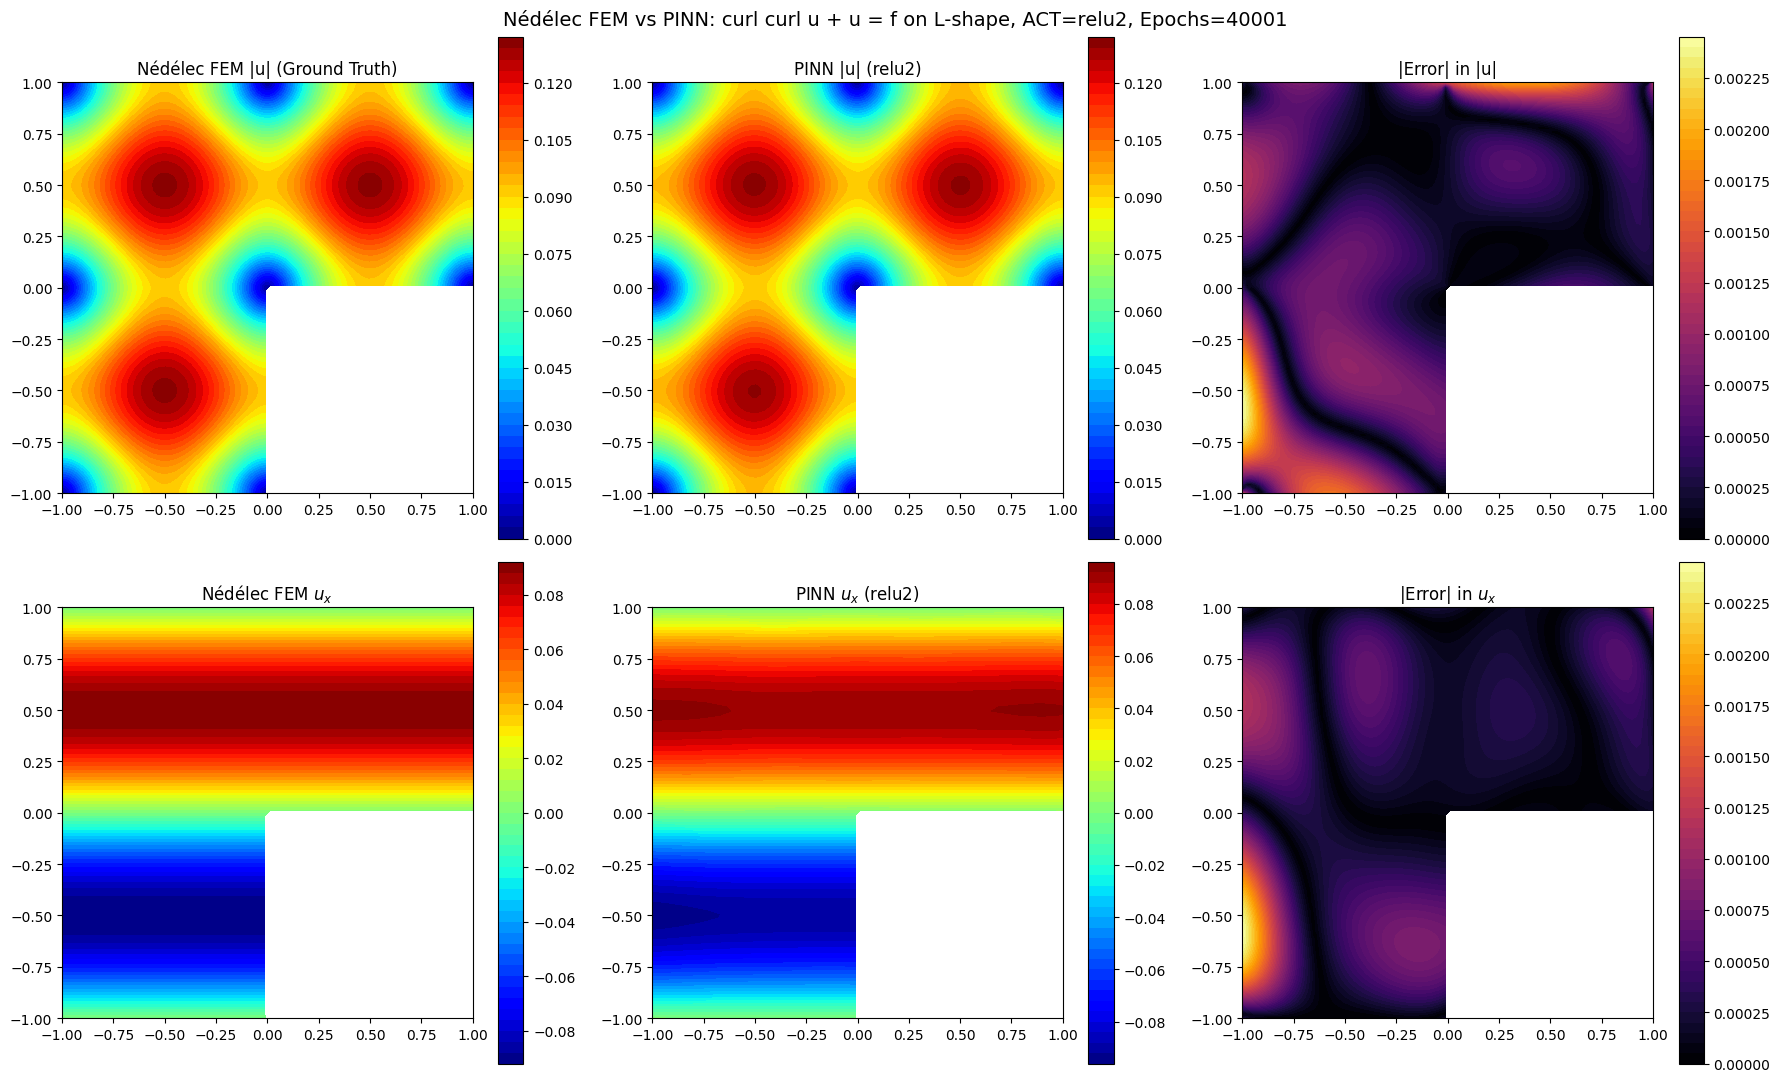


=== Error Statistics ===
  Max |u| error:  2.449825e-03
  Mean |u| error: 4.984996e-04
  L2 relative:    7.073519e-03


In [36]:
# ===================== 加载 FEM 网格数据并对比可视化 =====================
# 从 fem_grid_data.npz 加载预计算的 FEM 网格解 (无需 ngsolve!)
fem_grid = np.load('fem_grid_data.npz')
Xf, Yf = fem_grid['Xf'], fem_grid['Yf']
uxf, uyf, uf = fem_grid['uxf'], fem_grid['uyf'], fem_grid['uf']

# PINN 在同样网格上评估
ng = Xf.shape[0]
print(f'Evaluating PINN on {ng}x{ng} grid...')
Xp, Yp, uxp, uyp, up, mp = evaluate_on_grid(model, device, (-1, 1), (-1, 1), ng)

# --- FEM vs PINN 对比 (2×3 子图) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

im00 = axes[0,0].contourf(Xf, Yf, uf, levels=50, cmap='jet')
axes[0,0].set_title('Nédélec FEM |u| (Ground Truth)'); axes[0,0].set_aspect('equal'); fig.colorbar(im00, ax=axes[0,0])

im01 = axes[0,1].contourf(Xp, Yp, up, levels=50, cmap='jet')
axes[0,1].set_title(f'PINN |u| ({ACT_TYPE})'); axes[0,1].set_aspect('equal'); fig.colorbar(im01, ax=axes[0,1])

err_mag = np.abs(up - uf)
im02 = axes[0,2].contourf(Xf, Yf, err_mag, levels=50, cmap='inferno')
axes[0,2].set_title('|Error| in |u|'); axes[0,2].set_aspect('equal'); fig.colorbar(im02, ax=axes[0,2])

im10 = axes[1,0].contourf(Xf, Yf, uxf, levels=50, cmap='jet')
axes[1,0].set_title(r'Nédélec FEM $u_x$'); axes[1,0].set_aspect('equal'); fig.colorbar(im10, ax=axes[1,0])

im11 = axes[1,1].contourf(Xp, Yp, uxp, levels=50, cmap='jet')
axes[1,1].set_title(f'PINN $u_x$ ({ACT_TYPE})'); axes[1,1].set_aspect('equal'); fig.colorbar(im11, ax=axes[1,1])

err_ux = np.abs(uxp - uxf)
im12 = axes[1,2].contourf(Xf, Yf, err_ux, levels=50, cmap='inferno')
axes[1,2].set_title(r'|Error| in $u_x$'); axes[1,2].set_aspect('equal'); fig.colorbar(im12, ax=axes[1,2])

plt.suptitle(f'Nédélec FEM vs PINN: curl curl u + u = f on L-shape, ACT={ACT_TYPE}, Epochs={len(loss_history)}', fontsize=14)
plt.tight_layout(); plt.show()

print(f'\n=== Error Statistics ===')
print(f'  Max |u| error:  {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| error: {np.nanmean(err_mag):.6e}')
print(f'  L2 relative:    {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')


Evaluating PINN on zoom grid 100x100 near re-entrant corner...


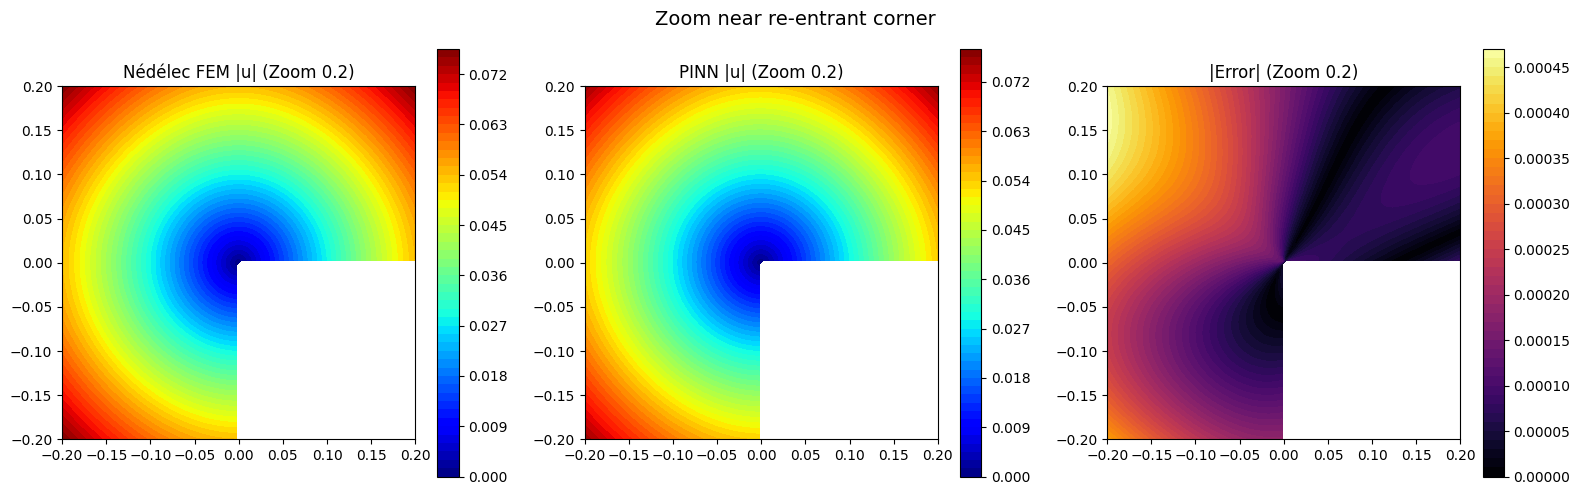

Zoom - Max err: 4.665179e-04, Mean err: 1.720013e-04


In [37]:
# ===================== Zoom-in 凹角附近误差分析 =====================
# 加载预计算的 FEM zoom 数据
Xfz, Yfz = fem_grid['Xfz'], fem_grid['Yfz']
ufz = fem_grid['ufz']

nz = Xfz.shape[0]
print(f'Evaluating PINN on zoom grid {nz}x{nz} near re-entrant corner...')
Xpz, Ypz, _, _, upz, _ = evaluate_on_grid(model, device, (-0.2, 0.2), (-0.2, 0.2), nz)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xfz, Yfz, ufz, levels=50, cmap='jet')
axes[0].set_title('Nédélec FEM |u| (Zoom 0.2)'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xpz, Ypz, upz, levels=50, cmap='jet')
axes[1].set_title('PINN |u| (Zoom 0.2)'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_z = np.abs(upz - ufz)
im2 = axes[2].contourf(Xfz, Yfz, err_z, levels=50, cmap='inferno')
axes[2].set_title('|Error| (Zoom 0.2)'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle('Zoom near re-entrant corner', fontsize=14); plt.tight_layout(); plt.show()
print(f'Zoom - Max err: {np.nanmax(err_z):.6e}, Mean err: {np.nanmean(err_z):.6e}')


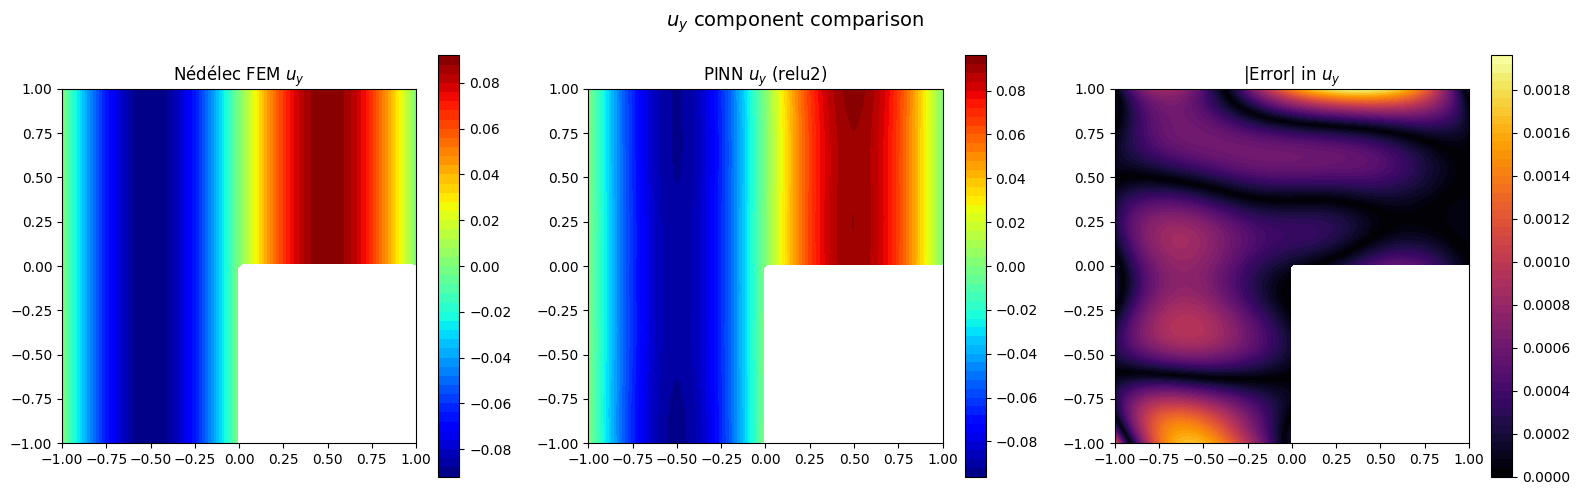

In [38]:
# ===================== u_y 分量对比可视化 =====================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xf, Yf, uyf, levels=50, cmap='jet')
axes[0].set_title(r'Nédélec FEM $u_y$'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xp, Yp, uyp, levels=50, cmap='jet')
axes[1].set_title(f'PINN $u_y$ ({ACT_TYPE})'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_uy = np.abs(uyp - uyf)
im2 = axes[2].contourf(Xf, Yf, err_uy, levels=50, cmap='inferno')
axes[2].set_title(r'|Error| in $u_y$'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle(r'$u_y$ component comparison', fontsize=14); plt.tight_layout(); plt.show()


In [39]:
# ===================== 保存模型与误差汇总 =====================
torch.save({'model_state_dict': model.state_dict(), 'activation': ACT_TYPE,
            'loss_history': loss_history, 'epochs': len(loss_history)}, 'pinn_curlcurl_model.pth')

print(f'\n{"="*55}')
print(f'  Final Results Summary')
print(f'{"="*55}')
print(f'  Equation:    curl curl u + u = f')
print(f'  Domain:      L-shape [-1,1]² \\ [0,1]×[-1,0]')
print(f'  FEM:         Nédélec edge elements (HCurl), order=3')
print(f'  BC:          u × n = 0 (tangential homogeneous)')
print(f'  f:           (sin(πy), sin(πx))')
print(f'  Activation:  {ACT_TYPE}')
print(f'  Total epochs:{len(loss_history)}')
print(f'  Final loss:  {loss_history[-1]:.6e}')
print(f'  Max |u| err: {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| err:{np.nanmean(err_mag):.6e}')
print(f'  L2 relative: {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')



  Final Results Summary
  Equation:    curl curl u + u = f
  Domain:      L-shape [-1,1]² \ [0,1]×[-1,0]
  FEM:         Nédélec edge elements (HCurl), order=3
  BC:          u × n = 0 (tangential homogeneous)
  f:           (sin(πy), sin(πx))
  Activation:  relu2
  Total epochs:40001
  Final loss:  3.281616e-06
  Max |u| err: 2.449825e-03
  Mean |u| err:4.984996e-04
  L2 relative: 7.073519e-03



$$\mathcal{L} = w_{\text{pde}} \cdot \mathcal{L}_{\text{pde}} + w_{\text{bc}} \cdot \mathcal{L}_{\text{bc}}$$

其中：
- $\mathcal{L}_{\text{pde}} = \frac{1}{N}\sum_i \|\nabla\times\nabla\times\mathbf{u}(\mathbf{x}_i) + \mathbf{u}(\mathbf{x}_i) - \mathbf{f}(\mathbf{x}_i)\|^2$ — **PDE 物理残差**
- $\mathcal{L}_{\text{bc}} = \frac{1}{M}\sum_j \|\mathbf{u}(\mathbf{x}_j^{\text{bc}}) - \mathbf{u}_{\text{bc}}\|^2$ — **边界条件**

